In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile, qasm3

First, let's define a simple quantum circuit. We will create an EPR pair and measure it.

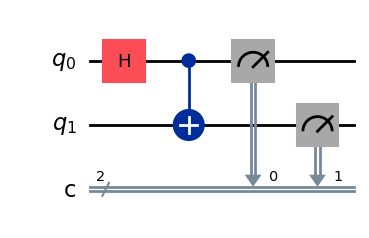

In [2]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0,1], [0,1])
qc.draw("mpl")

Now, let's convert it to OpenQASM.

In [ ]:
qasm3.dumps(qc)

'OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2] c;\nqubit[2] q;\nh q[0];\ncx q[0], q[1];\nc[0] = measure q[0];\nc[1] = measure q[1];\n'

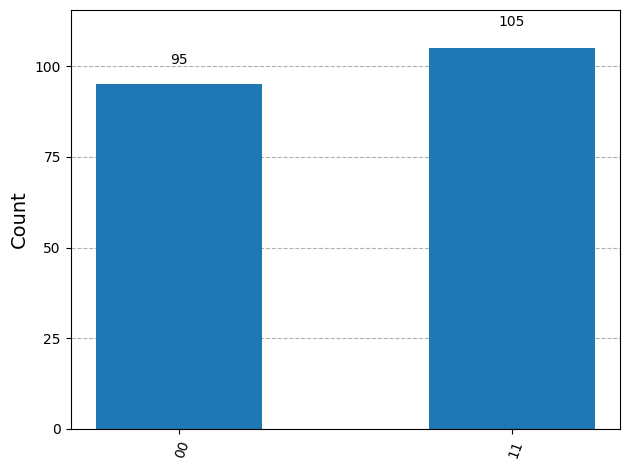

In [4]:
sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=200).result()
counts = result.get_counts()
plot_histogram(counts)